<a href="https://colab.research.google.com/github/cardinal-ship-it/Acend-NFT-Marketplace/blob/main/Modeling_non_linear_pattern_with_activation_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Non-linear activation function is the key to unlocking our models abillity to learn the complex, curved patterns found in the real world data.
# We will use the most popular and powerful activation function ReLu(rectified linear unit), to build a more sophisticated model,
# By adding ReLu activation, our moel can create multiple bends that can approximate the complex delivery time curve.

What we stand to achieve here



*   We will prepare the combined bike and car delivery dataz, this time applying a techniqe called normalization to help our model train more effectively
*   Build a non-linear neural network using ReLu activation function

*   Train our model to learn the complex, curved relationship in the data
*   Predict delivery times using our model and see if it can finally succed.







In [ ]:
!pip install helper_utils

  Preparing metadata (setup.py) ... done
  Created wheel for helper_utils: filename=helper_utils-0.0.8-py3-none-any.whl size=6081 sha256=0e2380320449ce313b3f9f08ce6dd622164c4bd3b16853dfa211b6dfcd02a1b7
  Stored in directory: /root/.cache/pip/wheels/0d/c9/0b/294fee31b3dc5173031699ea99432767ec851eef54c1982dd0
Successfully built helper_utils


In [ ]:
# Import dependencies needed
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import helper_utils as helper_utils

In [ ]:
# Let us prepare our data, this dataset will be combinedfor short and long distances for bikes and cars
distance = torch.tensor([[1.0],[1.5],[2.0],[2.5],[3.0],[3.5],[4.0],[4.5],[5.0],[5.5],[6.0],[6.5],[7.0],[7.5],[8.0],[8.5],[9.0],[9.5],[10.0],[10.5],[11.0],[11.5],[12.0],[12.5],[13.0],[13.5],[14.0],[14.5],[15.0],[15.5],[16.0],[16.5],[17.0],[17.5],[18.0],[18.5],[19.0],[19.5],[20.0]], dtype=torch.float32)
time = torch.tensor([[6.0],[9.0],[12.0],[15.0],[18.0],[21.0],[24.0],[27.0],[30.0],[33.0],[36.0],[39.0],[42.0],[45.0],[48.0],[51.0],[54.0],[57.0],[60.0],[63.0],[66.0],[69.0],[71.0],[74.0],[77.0],[80.0],[83.0],[86.0],[89.0],[91.0],[94.0],[97.0],[100.0],[103.0],[106.0],[109.0],[112.0]], dtype=torch.float32)

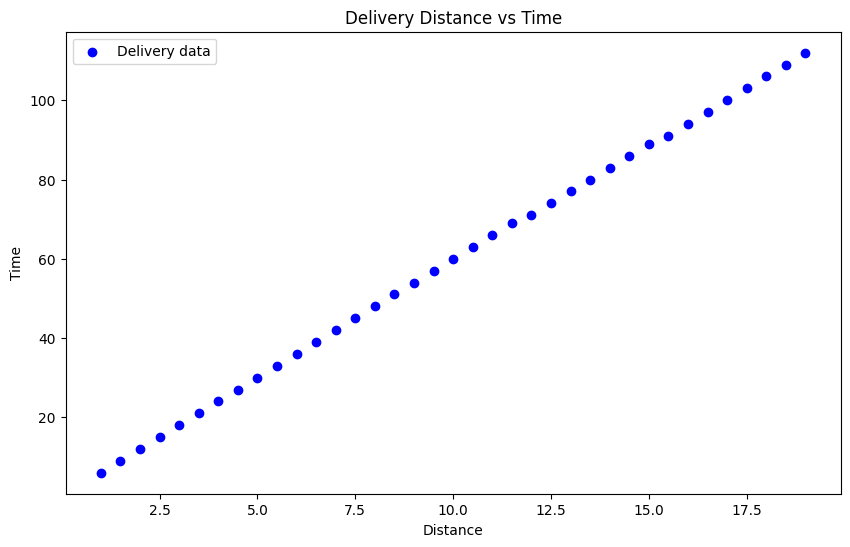

In [ ]:
plt.figure(figsize = (10,6))
plt.scatter(distance[:len(time)].numpy(), time.numpy(), c = 'blue', label = 'Delivery data')
plt.title('Delivery Distance vs Time')
plt.xlabel('Distance')
plt.ylabel('Time')
plt.legend()
plt.show()

In [ ]:
# We Normalize the data. Normalization is a process of preparing your data for training porposes
# Calculate the mean and standard deviation for the 'distance' tensor
Distance_mean = distance.mean()
Distance_std = distance.std()
# do same for time
Time_mean = time.mean()
Time_std = time.std()

In [ ]:
# We apply Standardization to bothe distance and time
distance_norm = (distance - Distance_mean)/Time_std
time_norm = (time - Time_mean)/Time_std
print(f'Distance mean: {distance_norm.mean()}')
print(f'Time mean: {time_norm.mean()}')

Distance mean: 3.82081061234274e-10
Time mean: -5.154996429723724e-08


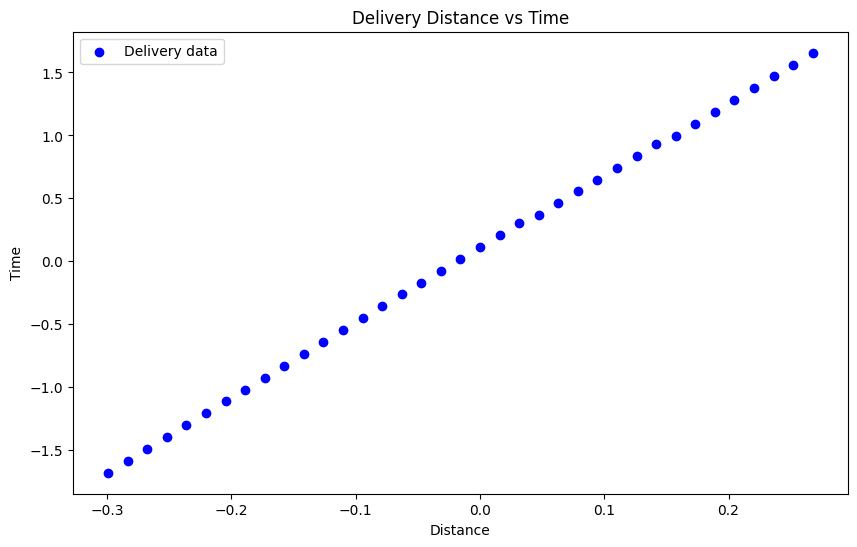

In [ ]:
plt.figure(figsize = (10,6))
plt.scatter(distance_norm[:len(time_norm)].numpy(), time_norm.numpy(), c = 'blue', label = 'Delivery data')
plt.title('Delivery Distance vs Time')
plt.xlabel('Distance')
plt.ylabel('Time')
plt.legend()
plt.show()

In [ ]:
# Let us build our non-linear model
torch.manual_seed(27)
model = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

In [ ]:
# Train our model
# First we define our loss function and the optimizer for training
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

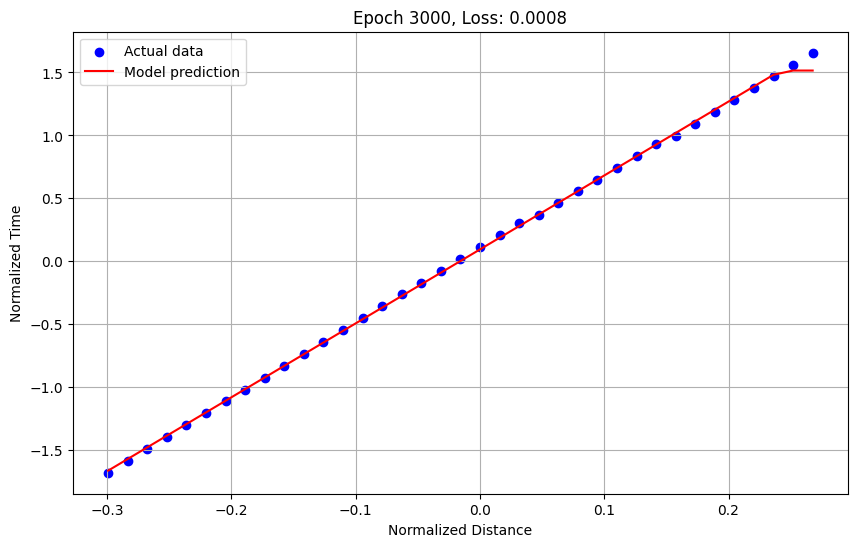


 Trainig update at epoch 3000.
Current Loss: 0.0007611053297296166


In [ ]:
from IPython.display import clear_output
# Training loop
for epoch in range(3000):
  optimizer.zero_grad() # Reset the optimizer's gradients
  output = model(distance_norm[:len(time_norm)]) # Make predictions (forward pass)
  loss = loss_function(output, time_norm) # calculate the loss
  loss.backward() # calculate adjustments (backward pass)
  optimizer.step() # Update the model's parameters

  # we will create a live plot for every 50 epochs
  if (epoch + 1)% 50==0:
    clear_output(wait = True) # Clear previous output for live update
    plt.figure(figsize = (10,6))
    plt.scatter(distance_norm[:len(time_norm)].numpy(), time_norm.numpy(), c='blue', label = 'Actual data')

    with torch.no_grad():
      # models input size matches the training data
      pred_time_norm = model(distance_norm[:len(time_norm)])
      plt.plot(distance_norm[:len(time_norm)].numpy(), pred_time_norm.numpy(), c = 'red', label = 'Model prediction')
      plt.title(f'Epoch {epoch + 1}, Loss: {loss.item():.4f}')
      plt.xlabel('Normalized Distance')
      plt.ylabel('Normalized Time')
      plt.legend()
      plt.grid(True)
      plt.show()
    print(f'\n Trainig update at epoch {epoch + 1}.') # Classify which epoch it is
    print(f'Current Loss: {loss.item()}')


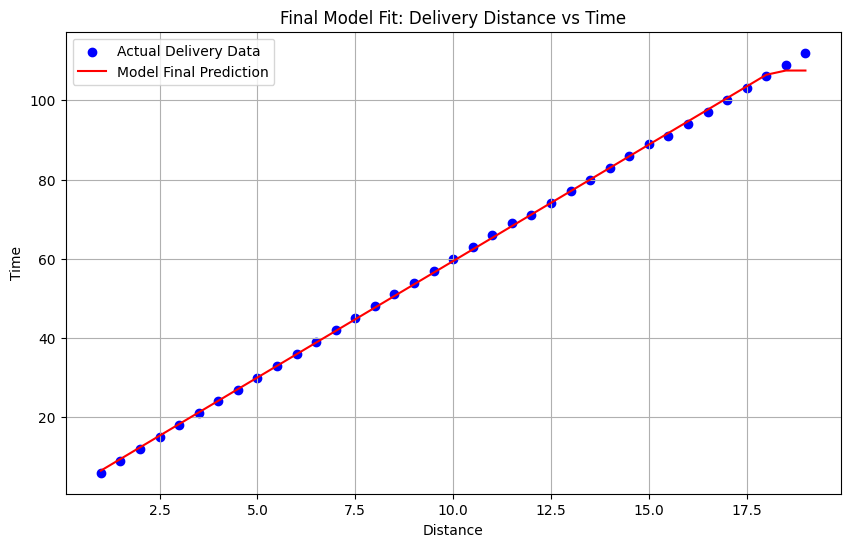

In [ ]:
# We will plot our model's final predicted curve against the original data point
# Get the model's predictions on the normalized distance
with torch.no_grad():
  pred_time_norm = model(distance_norm[:len(time_norm)])

  # Denormalize the predicted time
  pred_time = (pred_time_norm * Time_std) + Time_mean

  plt.figure(figsize = (10,6))
  plt.scatter(distance[:len(time)].numpy(), time.numpy(), c= 'blue', label = 'Actual Delivery Data')
  plt.plot(distance[:len(time)].numpy(), pred_time.numpy(), c = 'red', label = 'Model Final Prediction')
  plt.title('Final Model Fit: Delivery Distance vs Time')
  plt.xlabel('Distance')
  plt.ylabel('Time')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
# Let us make our prediction
distance_to_pred = 22.0
with torch.no_grad():
  # Now we normalize the input distance
  distance_tensor = torch.tensor([[distance_to_pred]], dtype = torch.float32)
  distance_norm1 = (distance_tensor - Distance_mean)/Distance_std
  # we get the normalized prediction
  pred_time_norm = model(distance_norm1)

  # We denormalize the result/output
  pred_time = (pred_time_norm * Time_std) + Time_mean

  # We make our decision based on the output
  # Corrected variable name from distance_to_predict to distance_to_pred
  # Corrected variable name from Predict_time_actual to pred_time
  # Corrected f-string format from .if to .1f
  print(f'Prediction for a {distance_to_pred}.mile delivery: {pred_time.item():.1f} minutes')
  # we check if the delivery is possible within the 45 minutes
  # Removed backslash and corrected variable name from predict_time_actual to pred_time
  if pred_time.item() > 45:
    print('\nDecision: Do Not Promise the Delivery in under 45mins.')
  # Using elif for clearer logical flow and corrected variable name
  elif distance_to_pred <= 7:
    print(f'\nDecision: Yes Delivery is Possible, since the distance is {distance_to_pred} miles(<=7mile), use a bike')
  # Final else for distance_to_pred > 5, corrected variable name
  else:
    print(f'\nDecision: Yes, delivery is possible. Since the distance is {distance_to_pred} miles(>7mile), Use a car.')

Prediction for a 22.0.mile delivery: 92.6 minutes

Decision: Do Not Promise the Delivery in under 45mins.
